In [1]:
#install required libraries
!pip install gensim -q
!pip install contractions -q
!pip install wordcloud -q
!pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 3.7 MB/s eta 0:00:00


In [2]:
#Import required libraries
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import contractions
import gensim.downloader as api

from collections import Counter
from wordcloud import WordCloud

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [16]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [17]:
#load datasets
train_df = pd.read_csv("/content/drive/MyDrive/AI ML/Data/train_movie_review.csv")
val_df = pd.read_csv("/content/drive/MyDrive/AI ML/Data/val_movie_review.csv")
test_df = pd.read_csv("/content/drive/MyDrive/AI ML/Data/test_movie_review.csv")

In [18]:
#combine training and validation datasets
df = pd.concat([train_df, val_df], axis=0)

text_col = "review"
label_col = "sentiment"

print(df.head())

   Unnamed: 0                                             review  sentiment
0        3774  Having avoided seeing the movie in the cinema,...          0
1       48396  With this movie I was really hoping that the i...          0
2        1980  Raymond Burr stars as an attorney caught up in...          0
3        6703  A lot people get hung up on this films tag as ...          1
4       28168  I was a fan of Buffy and hoped it would come t...          0


In [19]:
#Encode sentiment labels into numerical values
le = LabelEncoder()

df[label_col] = le.fit_transform(df[label_col])
test_df[label_col] = le.transform(test_df[label_col])

In [20]:
#initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

#function to clean and preprocess text data
def clean_text(text):

    text = contractions.fix(str(text).lower())

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"@\w+", "", text)

    text = re.sub(r"#\w+", "", text)

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [21]:
# apply text cleaning to training and testing datasets
df["clean_text"] = df[text_col].apply(clean_text)
test_df["clean_text"] = test_df[text_col].apply(clean_text)

print(df["clean_text"].head())

0    avoided seeing movie cinema buying dvd wife xm...
1    movie really hoping idea make hashed together ...
2    raymond burr star attorney caught murder best ...
3    lot people get hung film tag childrens film ce...
4    fan buffy hoped would come proper end angel go...
Name: clean_text, dtype: object


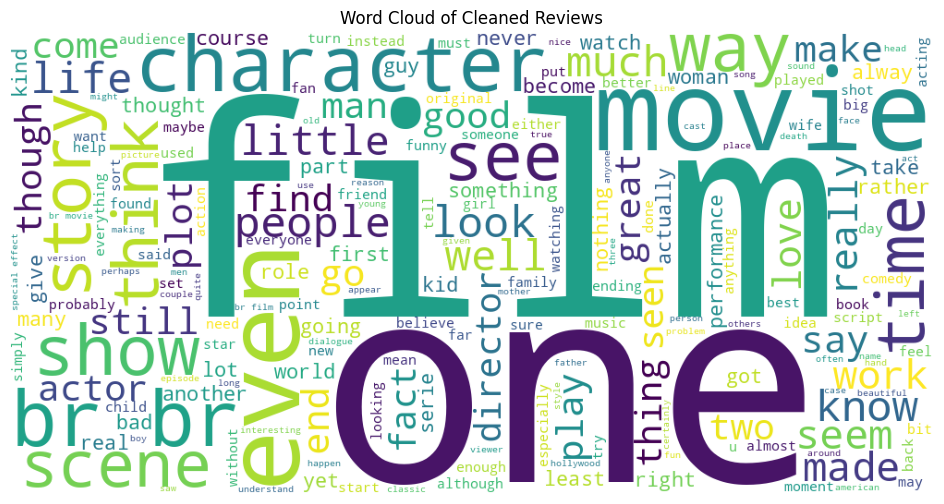

In [22]:
#generate word cloud for cleaned reviews
all_words = " ".join(df["clean_text"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(all_words)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud of Cleaned Reviews")
plt.show()

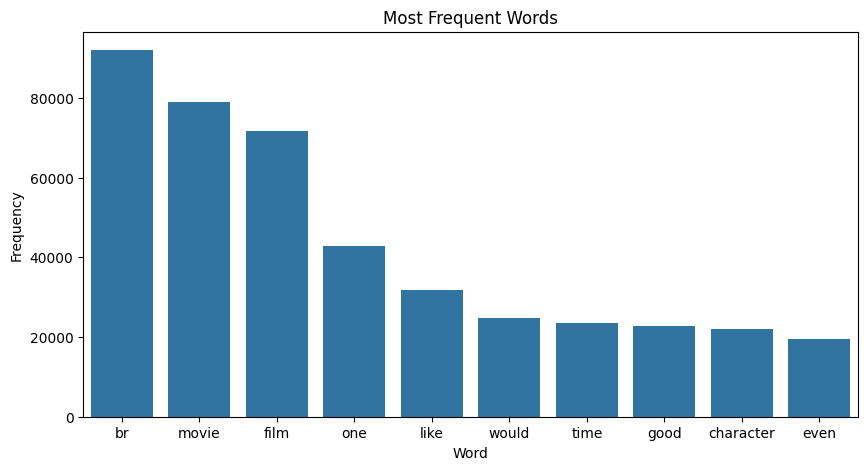

In [23]:
#display most frequent words in the dataset
words = all_words.split()

common_words = Counter(words).most_common(10)

common_df = pd.DataFrame(common_words, columns=["Word", "Frequency"])

plt.figure(figsize=(10,5))
sns.barplot(x="Word", y="Frequency", data=common_df)
plt.title("Most Frequent Words")
plt.show()


In [24]:
#split dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"],
    df[label_col],
    test_size=0.2,
    random_state=42
)

In [25]:
#convert text into sequences using Keras Tokenizer
vocab_size = 5000

tokenizer = Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(X_train)

train_sequences = tokenizer.texts_to_sequences(X_train)
test_sequences = tokenizer.texts_to_sequences(X_test)

In [26]:
#apply percentile based padding to ensure equal sequence lengths
sequence_lengths = [len(seq) for seq in train_sequences]

max_len = int(np.percentile(sequence_lengths, 95))

print("Padding Length:", max_len)

X_train_pad = pad_sequences(
    train_sequences,
    maxlen=max_len,
    padding='post'
)

X_test_pad = pad_sequences(
    test_sequences,
    maxlen=max_len,
    padding='post'
)


Padding Length: 248


In [27]:
# Simple RNN with trainable embedding layer
model_rnn = Sequential()

model_rnn.add(keras.Input(shape=(max_len,)))

model_rnn.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=64
    )
)

model_rnn.add(SimpleRNN(64))

model_rnn.add(Dropout(0.5))

model_rnn.add(Dense(1, activation='sigmoid'))

model_rnn.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_rnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 248, 64)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,321 (1.25 MB)

 Trainable params: 328,321 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# LSTM with trainable embedding layer
model_lstm = Sequential()

# Explicit input shape
model_lstm.add(keras.Input(shape=(max_len,)))

model_lstm.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=64
    )
)

model_lstm.add(LSTM(64))

model_lstm.add(Dropout(0.5))

model_lstm.add(Dense(1, activation='sigmoid'))

model_lstm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_lstm.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 248, 64)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 353,089 (1.35 MB)

 Trainable params: 353,089 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# load pretrained Word2Vec embeddings
print("Loading pretrained embeddings...")

embedding_model = api.load('word2vec-google-news-300')

embedding_dim = 300

word_index = tokenizer.word_index

embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in word_index.items():

    if i < vocab_size:

        if word in embedding_model:

            embedding_vector = embedding_model[word]
            embedding_matrix[i] = embedding_vector

Loading pretrained embeddings...


In [32]:
# LSTM with pretrained Word2Vec embeddings
model_lstm_w2v = Sequential()

model_lstm_w2v.add(keras.Input(shape=(max_len,)))

model_lstm_w2v.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=300,
        weights=[embedding_matrix],
        trainable=False
    )
)

model_lstm_w2v.add(LSTM(64))

model_lstm_w2v.add(Dropout(0.5))

model_lstm_w2v.add(Dense(1, activation='sigmoid'))

model_lstm_w2v.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_lstm_w2v.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 248, 300)       │     1,500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        93,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,593,505 (6.08 MB)

 Trainable params: 93,505 (365.25 KB)

 Non-trainable params: 1,500,000 (5.72 MB)

In [33]:
#early stopping callback to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [34]:
#train the Simple RNN model
history_rnn = model_rnn.fit(
    X_train_pad,
    y_train,
    validation_data=(X_test_pad, y_test),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)


Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 65s 62ms/step - accuracy: 0.5001 - loss: 0.7012 - val_accuracy: 0.4927 - val_loss: 0.6943
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 81s 61ms/step - accuracy: 0.5067 - loss: 0.7028 - val_accuracy: 0.4870 - val_loss: 0.6945
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 62s 62ms/step - accuracy: 0.4994 - loss: 0.6960 - val_accuracy: 0.4940 - val_loss: 0.6934
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 60s 60ms/step - accuracy: 0.5054 - loss: 0.6943 - val_accuracy: 0.4949 - val_loss: 0.6950
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 67s 67ms/step - accuracy: 0.5020 - loss: 0.6949 - val_accuracy: 0.4926 - val_loss: 0.6937
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 75s 60ms/step - accuracy: 0.5060 - loss: 0.6946 - val_accuracy: 0.5027 - val_loss: 0.6934
Epoch 7/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 62s 62ms/step - accuracy: 0.5039 - loss: 0.6949 - val_accuracy: 0.5052 - val_loss: 0.6932
Epoch 8/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 60s 60ms/step - accuracy: 0.5023 -

In [36]:
#create LSTM model
model_lstm = Sequential()

model_lstm.add(keras.Input(shape=(max_len,)))

model_lstm.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=64
    )
)

model_lstm.add(LSTM(64))

model_lstm.add(Dropout(0.5))

model_lstm.add(Dense(1, activation='sigmoid'))


In [37]:
#compile LSTM model
model_lstm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


In [38]:
#train the LSTM model model
history_lstm = model_lstm.fit(
    X_train_pad,
    y_train,
    validation_data=(X_test_pad, y_test),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 127s 125ms/step - accuracy: 0.5040 - loss: 0.6937 - val_accuracy: 0.5113 - val_loss: 0.6928
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 139s 122ms/step - accuracy: 0.5061 - loss: 0.6924 - val_accuracy: 0.5186 - val_loss: 0.6900
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 143s 124ms/step - accuracy: 0.5167 - loss: 0.6848 - val_accuracy: 0.4989 - val_loss: 0.6913
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 142s 123ms/step - accuracy: 0.5204 - loss: 0.6712 - val_accuracy: 0.5214 - val_loss: 0.6898
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 120s 120ms/step - accuracy: 0.6712 - loss: 0.6054 - val_accuracy: 0.7225 - val_loss: 0.5973
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 121s 121ms/step - accuracy: 0.7295 - loss: 0.5750 - val_accuracy: 0.6074 - val_loss: 0.6756
Epoch 7/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 122s 122ms/step - accuracy: 0.7078 - loss: 0.5865 - val_accuracy: 0.6702 - val_loss: 0.6500
Epoch 8/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 144s 124ms/step - ac

In [40]:
#train the pretrained embedding LSTM model
history_w2v = model_lstm_w2v.fit(
    X_train_pad,
    y_train,
    validation_data=(X_test_pad, y_test),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 207s 204ms/step - accuracy: 0.5099 - loss: 0.6926 - val_accuracy: 0.5156 - val_loss: 0.6915
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 263s 205ms/step - accuracy: 0.5139 - loss: 0.6870 - val_accuracy: 0.5146 - val_loss: 0.6917
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 224s 224ms/step - accuracy: 0.5065 - loss: 0.6935 - val_accuracy: 0.4963 - val_loss: 0.6912


In [44]:
#evaluate all models using accuracy
rnn_acc = model_rnn.evaluate(X_test_pad, y_test)[1]

lstm_acc = model_lstm.evaluate(X_test_pad, y_test)[1]

w2v_acc = model_lstm_w2v.evaluate(X_test_pad, y_test)[1]

print("\nRNN Accuracy:", rnn_acc)
print("LSTM Accuracy:", lstm_acc)
print("Pretrained Embedding LSTM Accuracy:", w2v_acc)

250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.5052 - loss: 0.6931
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.8393 - loss: 0.3989
250/250 ━━━━━━━━━━━━━━━━━━━━ 22s 87ms/step - accuracy: 0.5156 - loss: 0.6915

RNN Accuracy: 0.5052499771118164
LSTM Accuracy: 0.8392500281333923
Pretrained Embedding LSTM Accuracy: 0.515625


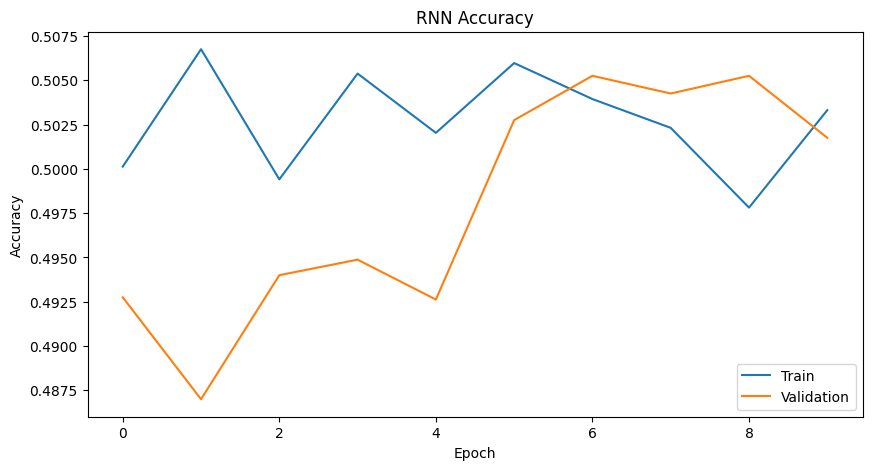

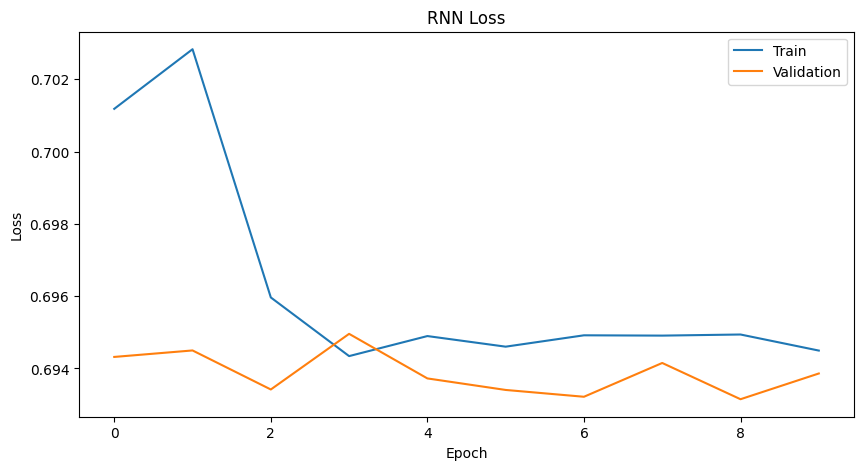

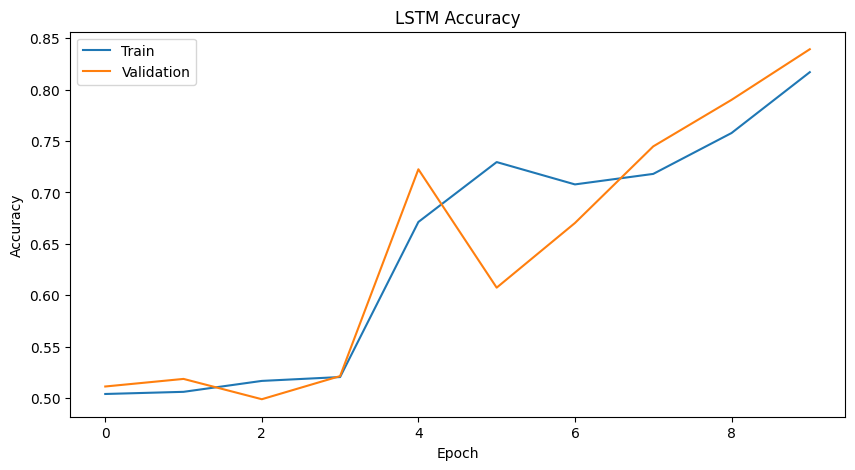

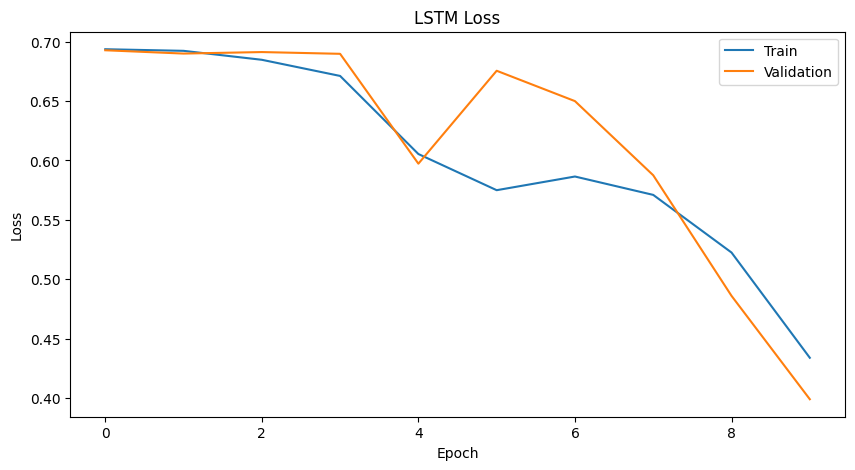

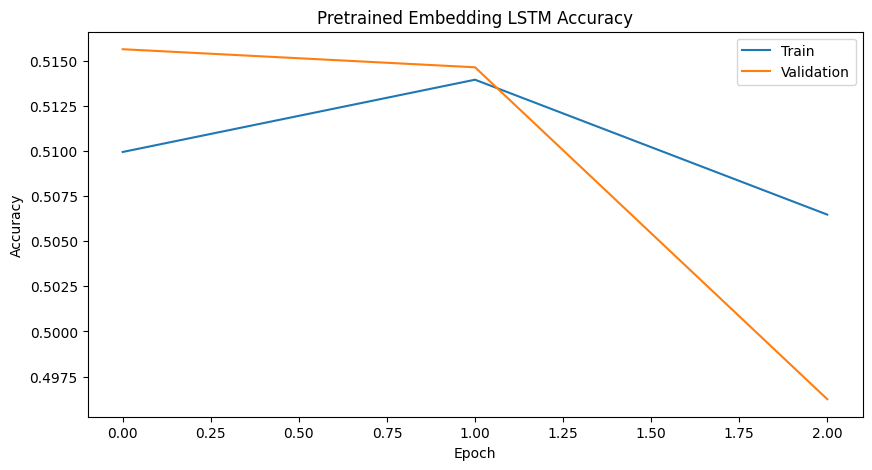

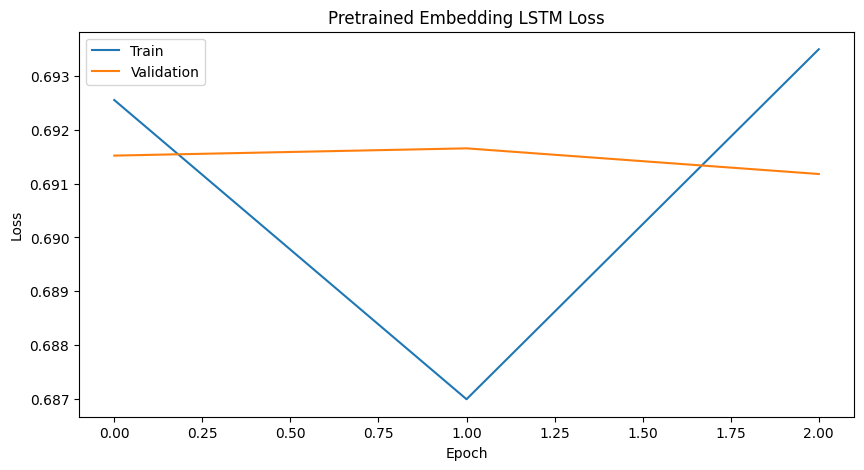

In [45]:
#function to plot training and validation accuracy/loss
def plot_history(history, title):

    # Accuracy
    plt.figure(figsize=(10,5))

    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])

    plt.title(title + " Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    plt.legend(['Train', 'Validation'])

    plt.show()

    # Loss
    plt.figure(figsize=(10,5))

    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])

    plt.title(title + " Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.legend(['Train', 'Validation'])

    plt.show()

plot_history(history_rnn, "RNN")
plot_history(history_lstm, "LSTM")
plot_history(history_w2v, "Pretrained Embedding LSTM")

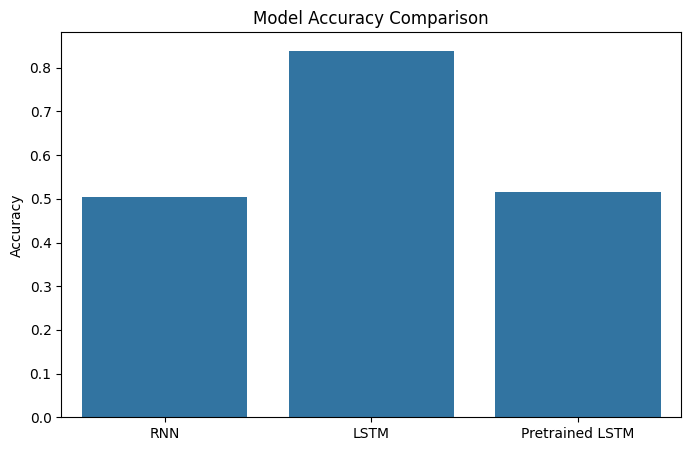

In [46]:
#compare accuracy of all models
model_names = [
    "RNN",
    "LSTM",
    "Pretrained LSTM"
]

accuracies = [
    rnn_acc,
    lstm_acc,
    w2v_acc
]

plt.figure(figsize=(8,5))

sns.barplot(
    x=model_names,
    y=accuracies
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step


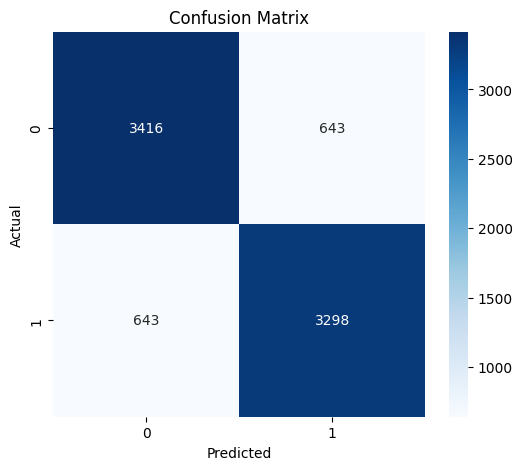

In [47]:
#generate confusion matrix for LSTM model predictions
predictions = (
    model_lstm.predict(X_test_pad) > 0.5
).astype(int).flatten()

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [49]:
#display classification report
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.84      0.84      0.84      4059
           1       0.84      0.84      0.84      3941

    accuracy                           0.84      8000
   macro avg       0.84      0.84      0.84      8000
weighted avg       0.84      0.84      0.84      8000



In [50]:
#display misclassified examples for error analysis
print("\nMISCLASSIFIED EXAMPLES\n")

count = 0

for i in range(len(predictions)):

    if predictions[i] != y_test.iloc[i]:

        print("TEXT:")
        print(X_test.iloc[i])

        print("\nACTUAL:", y_test.iloc[i])
        print("PREDICTED:", predictions[i])

        print("-" * 50)

        count += 1

    if count == 3:
        break



MISCLASSIFIED EXAMPLES

TEXT:
perhaps director trying another pirate good garland kelly musical lame musical epoch fall flat sinatra kathryn graysons voice blend well chemistry together lack spark premise sinatra sweet guy try impersonate late bandito father okay seems awkward role amazing wonderful sinatra take rather insipid song make seem special phrasing eloquence singer make want hear grayson sings song hard believe singing something entirely different nearly interesting big moment love find suit perfectly show ability photography lucious star look appealing costume set costars mildred natwick j carroll nash put lot energy making impossible work aside sinatra singing strange menageatois dance ricardo montalban cyd charisse ann miller fascinating weird montalban charisse wonderful dancing team number real oddity

ACTUAL: 0
PREDICTED: 1
--------------------------------------------------
TEXT:
cannot seeing movie grow france spent least year like know ever make outside french cultur

In [51]:
print("""
Possible Reasons for Errors:
1. Some reviews may contain sarcasm or mixed sentiments.
2. Short reviews provide limited context.
3. Unknown words may not exist in pretrained embeddings.
4. Some sentences may contain ambiguous meaning.
""")

print("""
Potential Improvements:
1. Use Bidirectional LSTM.
2. Increase dataset size.
3. Use larger pretrained embeddings.
4. Tune hyperparameters.
5. Use transformer-based models like BERT.
""")



Possible Reasons for Errors:
1. Some reviews may contain sarcasm or mixed sentiments.
2. Short reviews provide limited context.
3. Unknown words may not exist in pretrained embeddings.
4. Some sentences may contain ambiguous meaning.


Potential Improvements:
1. Use Bidirectional LSTM.
2. Increase dataset size.
3. Use larger pretrained embeddings.
4. Tune hyperparameters.
5. Use transformer-based models like BERT.



In [54]:
#build Gradio GUI for real-time movie review sentiment prediction
import gradio as gr

def predict_review(review):

    review = clean_text(review)

    seq = tokenizer.texts_to_sequences([review])

    padded = pad_sequences(seq, maxlen=max_len, padding='post')

    pred = model_lstm.predict(padded)[0][0]

    if pred > 0.4:
        return "Positive"
    else:
        return "Negative"

interface = gr.Interface(
    fn=predict_review,
    inputs=gr.Textbox(lines=3, placeholder="Enter movie review here..."),
    outputs="text",
    title="Movie Review Sentiment Analysis"
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b7f6cf37b1d6694a08.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
